<a href="https://colab.research.google.com/github/mohammedshamilm7890/Flight-Price-Prediction/blob/main/Flight_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/Clean_Dataset.csv")

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
154689,154689,Indigo,6E-6684,Hyderabad,Night,zero,Night,Delhi,Economy,2.25,21.0,2694.0
154690,154690,Indigo,6E-2349,Hyderabad,Night,zero,Late_Night,Delhi,Economy,2.25,21.0,2694.0
154691,154691,Air_India,AI-559,Hyderabad,Early_Morning,zero,Morning,Delhi,Economy,2.50,21.0,2696.0
154692,154692,Indigo,6E-2248,Hyderabad,Afternoon,zero,Evening,Delhi,Economy,2.25,21.0,3191.0


In [ ]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0


In [ ]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
154689,154689,Indigo,6E-6684,Hyderabad,Night,zero,Night,Delhi,Economy,2.25,21.0,2694.0
154690,154690,Indigo,6E-2349,Hyderabad,Night,zero,Late_Night,Delhi,Economy,2.25,21.0,2694.0
154691,154691,Air_India,AI-559,Hyderabad,Early_Morning,zero,Morning,Delhi,Economy,2.50,21.0,2696.0
154692,154692,Indigo,6E-2248,Hyderabad,Afternoon,zero,Evening,Delhi,Economy,2.25,21.0,3191.0
154693,154693,Indigo,6E-643,Hyde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154694 entries, 0 to 154693
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        154694 non-null  int64  
 1   airline           154694 non-null  object 
 2   flight            154694 non-null  object 
 3   source_city       154694 non-null  object 
 4   departure_time    154693 non-null  object 
 5   stops             154693 non-null  object 
 6   arrival_time      154693 non-null  object 
 7   destination_city  154693 non-null  object 
 8   class             154693 non-null  object 
 9   duration          154693 non-null  float64
 10  days_left         154693 non-null  float64
 11  price             154693 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 14.2+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,1
stops,1
arrival_time,1
destination_city,1
class,1
duration,1


In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_616/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
154689,154689,Indigo,6E-6684,Hyderabad,Night,zero,Night,Delhi,Economy,2.25,21.0,2694.0
154690,154690,Indigo,6E-2349,Hyderabad,Night,zero,Late_Night,Delhi,Economy,2.25,21.0,2694.0
154691,154691,Air_India,AI-559,Hyderabad,Early_Morning,zero,Morning,Delhi,Economy,2.50,21.0,2696.0
154692,154692,Indigo,6E-2248,Hyderabad,Afternoon,zero,Evening,Delhi,Economy,2.25,21.0,3191.0


In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 449.24717508646046
MSE: 1258417.4145826013
RMSE: 1121.7920549650016
R2 Score: 0.9075311009451738


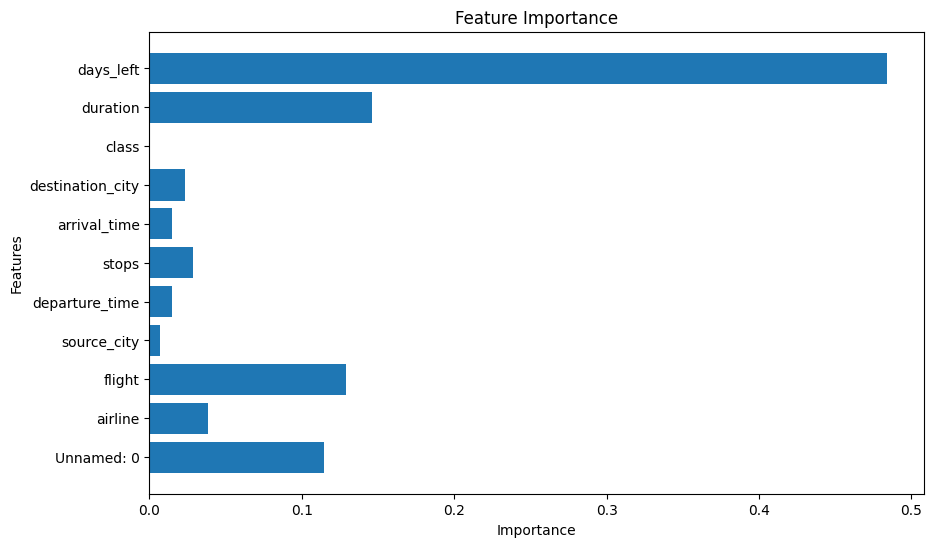

In [ ]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()